In [1]:
import py3dep
import rioxarray            # registers the .rio accessor we use to reproject
import xrspatial
import matplotlib.pyplot as plt
from pyproj import Transformer

In [2]:
# Maple Villa trailhead, Intervale NH (latitude, longitude)
trail_lat = 44.101448
trail_lon = -71.143607

# 3DEP wants the box as (west, south, east, north) in lon/lat degrees.
# Buffer the trailhead ~2 km in each direction.
buffer_lat = 0.018   # ~2 km north-south
buffer_lon = 0.025   # ~2 km east-west at this latitude

bbox = (
    trail_lon - buffer_lon,  # west
    trail_lat - buffer_lat,  # south
    trail_lon + buffer_lon,  # east
    trail_lat + buffer_lat,  # north
)
print(bbox)

(-71.16860700000001, 44.083448, -71.118607, 44.119448)


In [3]:
py3dep.check_3dep_availability(bbox)

{'1m': True,
 '3m': False,
 '5m': False,
 '10m': True,
 '30m': True,
 '60m': False,
 'topobathy': False}

In [4]:
# Start at 10 m: fast, reliable, plenty for a first look.
dem = py3dep.get_dem(bbox, resolution=10)

# Reproject into EPSG:5070 (CONUS Albers) — our standing project convention.
dem = dem.rio.reproject(5070)
dem

<xarray.DataArray 'elevation' (y: 579, x: 577)> Size: 1MB
array([[419.12772, 421.97784, 426.82516, ..., 510.30396, 512.951  ,
        514.163  ],
       [419.12772, 420.90823, 423.15802, ..., 511.12827, 512.4302 ,
        513.8499 ],
       [418.38934, 420.90823, 420.91272, ..., 511.12827, 513.80444,
        515.40985],
       ...,
       [406.94037, 405.99307, 405.0135 , ..., 218.80193, 218.68622,
        218.48001],
       [409.36017, 408.51395, 407.64694, ..., 218.35606, 218.24754,
        218.12012],
       [409.36017, 410.97592, 410.23676, ..., 217.98035, 217.87328,
        217.64104]], shape=(579, 577), dtype=float32)
Coordinates:
  * y            (y) float64 5kB 2.606e+06 2.606e+06 ... 2.601e+06 2.601e+06
  * x            (x) float64 5kB 1.958e+06 1.958e+06 ... 1.963e+06 1.963e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001
    _FillValue:           nan

In [5]:
# Convert the trailhead from lon/lat to EPSG:5070 so it lines up with the DEM.
to_5070 = Transformer.from_crs(4326, 5070, always_xy=True)
trail_x, trail_y = to_5070.transform(trail_lon, trail_lat)

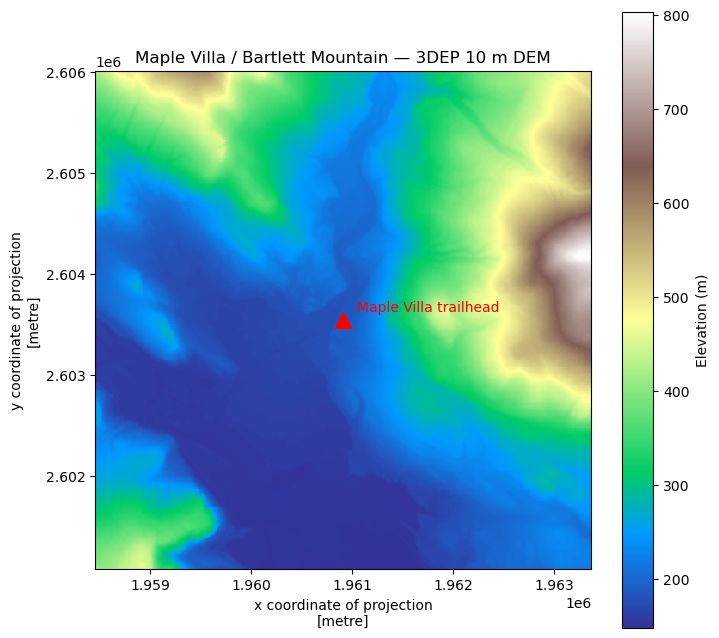

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))
dem.plot(ax=ax, cmap="terrain", cbar_kwargs={"label": "Elevation (m)"})
ax.plot(trail_x, trail_y, marker="^", color="red", markersize=12)
ax.annotate("Maple Villa trailhead", (trail_x, trail_y),
            textcoords="offset points", xytext=(10, 6), color="red")
ax.set_title("Maple Villa / Bartlett Mountain — 3DEP 10 m DEM")
ax.set_aspect("equal")
plt.show()

In [7]:
# Pitch: slope steepness in degrees, derived from the DEM.
slope = xrspatial.slope(dem)
slope

<xarray.DataArray 'slope' (y: 579, x: 577)> Size: 1MB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 16.609211 , 20.29336  , ..., 13.141136 , 11.7133665,
               nan],
       [       nan, 15.100213 , 12.370308 , ..., 13.518626 , 14.783444 ,
               nan],
       ...,
       [       nan, 21.060368 , 20.44356  , ...,  2.929235 ,  2.5697658,
               nan],
       [       nan, 14.958513 , 19.354975 , ...,  2.7167919,  2.926343 ,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(579, 577), dtype=float32)
Coordinates:
  * y            (y) float64 5kB 2.606e+06 2.606e+06 ... 2.601e+06 2.601e+06
  * x            (x) float64 5kB 1.958e+06 1.958e+06 ... 1.963e+06 1.963e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001
    _FillValue:           nan

In [8]:
# Aspect: the compass direction each slope faces (0/360 = N, 90 = E, 180 = S, 270 = W).
aspect = xrspatial.aspect(dem)
aspect

<xarray.DataArray 'aspect' (y: 579, x: 577)> Size: 1MB
array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan, 244.32092 , 222.0192  , ..., 282.5257  , 285.5426  ,
               nan],
       [       nan, 234.23643 , 221.6678  , ..., 288.7097  , 294.98428 ,
               nan],
       ...,
       [       nan,  19.888414,  19.524023, ..., 158.27972 , 149.19266 ,
               nan],
       [       nan,  14.264332,  22.650974, ..., 150.71835 , 160.97653 ,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], shape=(579, 577), dtype=float32)
Coordinates:
  * y            (y) float64 5kB 2.606e+06 2.606e+06 ... 2.601e+06 2.601e+06
  * x            (x) float64 5kB 1.958e+06 1.958e+06 ... 1.963e+06 1.963e+06
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    scale_factor:         1.0
    add_offset:           0.0
    units:                m
    vertical_datum:       NAVD88
    vertical_resolution:  0.001
    _FillValue:           nan

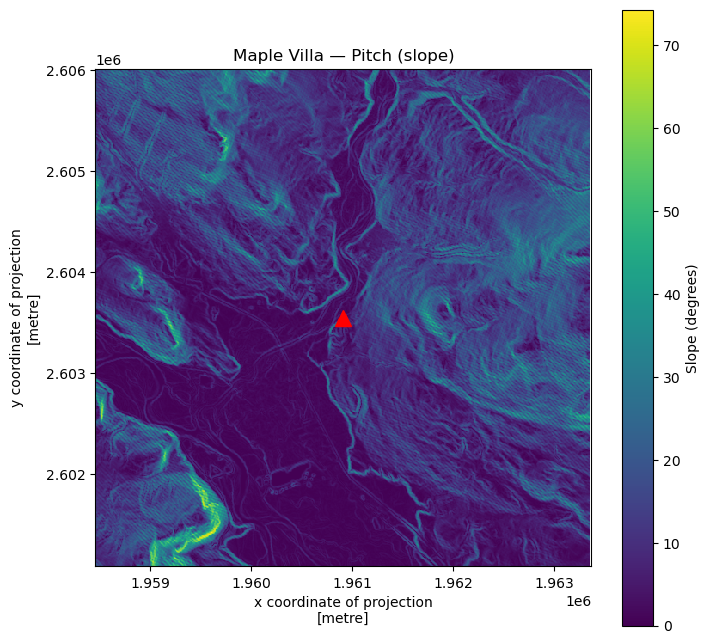

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
slope.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "Slope (degrees)"})
ax.plot(trail_x, trail_y, marker="^", color="red", markersize=12)
ax.set_title("Maple Villa — Pitch (slope)")
ax.set_aspect("equal")
plt.show()

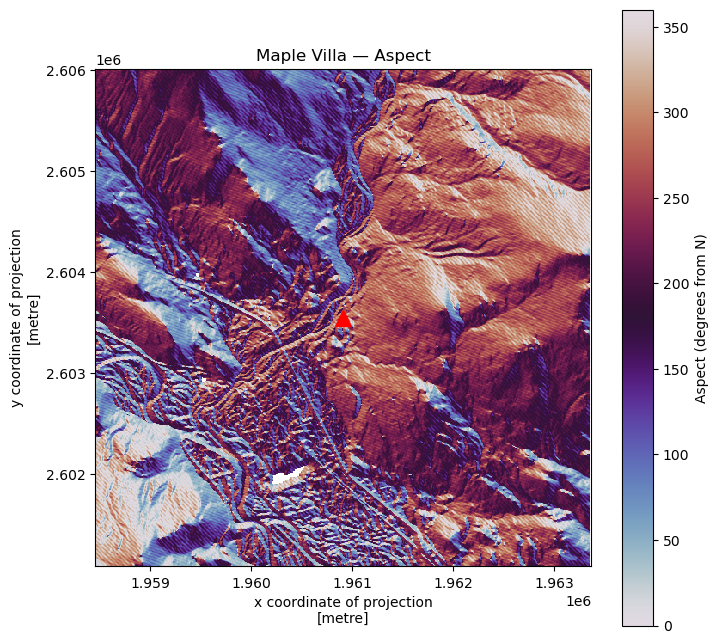

In [11]:
# Aspect is meaningless where the ground is flat; xrspatial marks those -1.
# Hide them, and lock the color scale to aspect's true 0-360 range.
aspect_clean = aspect.where(aspect >= 0)

fig, ax = plt.subplots(figsize=(8, 8))
aspect_clean.plot(ax=ax, cmap="twilight", vmin=0, vmax=360,
                  cbar_kwargs={"label": "Aspect (degrees from N)"})
ax.plot(trail_x, trail_y, marker="^", color="red", markersize=12)
ax.set_title("Maple Villa — Aspect")
ax.set_aspect("equal")
plt.show()

In [12]:
print("DEM grid shape:", dem.shape)
print("Slope range:", float(slope.min()), "to", float(slope.max()))
print("Aspect range:", float(aspect.min()), "to", float(aspect.max()))

DEM grid shape: (579, 577)
Slope range: 0.0 to 74.25216674804688
Aspect range: -1.0 to 359.9960632324219


In [13]:
def score_pitch(slope_deg):
    """Score slope steepness 0-1 for skiability.
    Ramps up from ~12 degrees, full score across the broad skiable range,
    and stays high into steep/expert terrain. Steepness *danger* is handled
    separately in the Hazard layer, not penalized here."""
    s = slope_deg
    score = xr.where(
        s < 12, 0.0,                               # too flat to ski
        xr.where(s < 25, (s - 12) / 13,            # ramp up 12 -> 25
        1.0))                                      # 25+ stays fully skiable
    return score

pitch_score = score_pitch(slope)

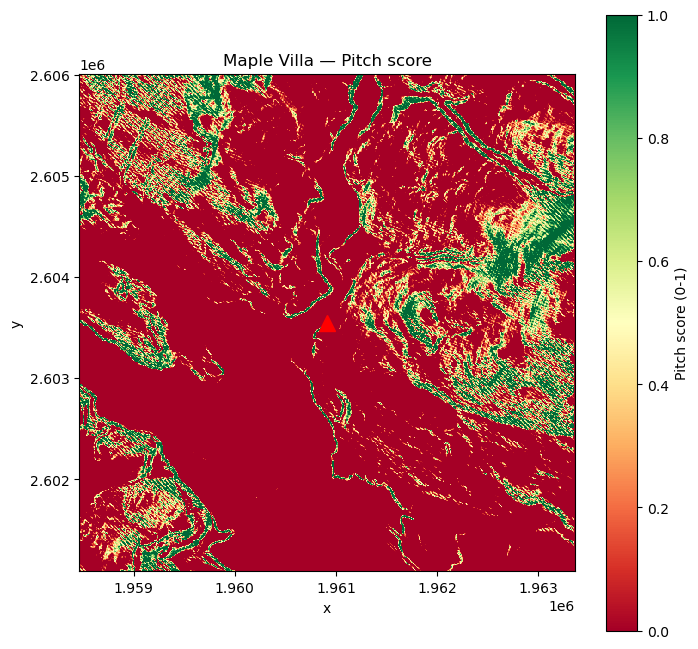

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
pitch_score.plot(ax=ax, cmap="RdYlGn", vmin=0, vmax=1,
                 cbar_kwargs={"label": "Pitch score (0-1)"})
ax.plot(trail_x, trail_y, marker="^", color="red", markersize=12)
ax.set_title("Maple Villa — Pitch score")
ax.set_aspect("equal")
plt.show()